In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os, glob
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import nltk
nltk.download('punkt_tab', quiet=True)

True

In [2]:
# sets fontsize etc. appropriate for presentation/paper, etc.
sns.set(context='talk', style='white', palette='deep')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'], mpl.rcParams['ytick.direction'] = 'in', 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'], mpl.rcParams['axes.spines.right'] = False, False

In [3]:
def norm01(x): return (x - np.min(x)) / (np.max(x) - np.min(x))

### Objective
Consider continuous input or output (stim or recall) token stream for 1 random story. Using different colors, line plot how locational or social a word is (each normed 0 to 1) per token. Note that it is ok that likely fewer tokens (and hence fewer x-vals) will exist in the recall data.

In [4]:
story_data = pd.read_csv('../../input_data/narrative/TableS4.csv')[['story', 'storyText']]
story_data.head()

,story,storyText
0,11,"A bell chimed as the door swung open, and Sadi..."
1,11,Thomas had been thinking about breaking up wit...
2,11,The restaurant he had chosen to meet at was re...
3,11,There was black and white checkerboard tiling ...
4,11,"Thomas stood up and gave Sadie a side hug, ask..."


In [5]:
# create story2text, which, for each unique story val, maps text that is concatenated across rows with that story val
story2text = story_data.groupby('story')['storyText'].apply(lambda x: ' '.join(x)).to_dict()
print(f'#stories: {len(story2text)}')
print(f'story2text example: {list(story2text.items())[0]}')

#stories: 16
story2text example: (11, 'A bell chimed as the door swung open, and Sadie entered to find Thomas, who was dreading the approaching breakup conversation he was about to start, ruminating at the bar. Thomas had been thinking about breaking up with her for 2 months now. The restaurant he had chosen to meet at was reminiscent of a diner from the 70’s. There was black and white checkerboard tiling on the floor, a long bar in the front, and booths and stools with red, leather upholstery.  Thomas stood up and gave Sadie a side hug, asking quickly, “How was your day?” She clung onto him, “It was okay- I missed you today.” He looked away and addressed the hostess coming towards them, “Can we have a booth in the back?” She shrugged and after loudly popping her bubblegum replied, “Sure, honey.” The hostess seated them at a booth in the back corner of the diner.   Sadie slipped into the cushioned seat and grabbed Thomas’ hand. “Tell me about your day!” she sang. Thomas looked away and

In [6]:
recall_data = pd.read_csv('../../input_data/narrative/ScriptPriming/behavior/online_memory_data.csv')[['story', 'recall']]
recall_data.sort_values('story', inplace=True)
print(f'#subjs: {len(recall_data)}')
print(recall_data['story'].value_counts())
recall_data.head()

#subjs: 375
story
11    29
12    28
22    28
13    26
32    26
33    25
23    24
14    22
21    22
41    22
42    21
43    21
44    21
24    20
31    20
34    20
Name: count, dtype: int64


,story,recall
1,11,Thomas was waiting for Sadie inside a restaura...
70,11,Thomas is meeting Sadie with the intention of ...
310,11,an argument between two people in the restaurant
72,11,Thomas arrives at the restaurant to break up w...
312,11,"After a few months of thinking, Thomas decided..."


In [7]:
# set model refs
model = SentenceTransformer('all-MiniLM-L6-v2')
loc_ref = model.encode(["a description of a place, setting, location, building, or room"])
soc_ref = model.encode(["a description involving people, characters, social interaction, or conversation"])

# setup story/data text
story_words = nltk.word_tokenize(story2text[11])
len_words, step = len(story_words), .1

# per window of text, correlate text with ref
locational_info_per_window, social_info_per_window = [], []
for prop_text in np.arange(0,1,step):
    window_words = ' '.join(story_words[int(prop_text*len_words):int((prop_text+step)*len_words)])
    window_emb = model.encode([window_words])

    locational_info_per_window.append(cosine_similarity(window_emb, loc_ref)[0][0])
    social_info_per_window.append(cosine_similarity(window_emb, soc_ref)[0][0])


/home/nuttidalab/miniconda3/envs/narrative_map/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

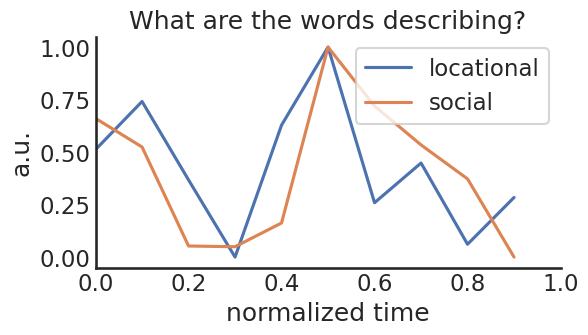

In [8]:
fig, ax = plt.subplots(figsize=(6,3))
ax.set(title='What are the words describing?',
       xlabel='normalized time', ylabel='a.u.',
       xlim=(0,1))

ax.plot(np.arange(0,1,step), norm01(np.array(locational_info_per_window)), label='locational')
ax.plot(np.arange(0,1,step), norm01(np.array(social_info_per_window)), label='social')

plt.legend()
plt.show()